In [1]:
!pip install torch scikit-learn matplotlib -q

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [27]:
# Cell 2 — Load data
BASE = "/content/gdrive/Shareddrives/FML_FINAL/Data"

X = np.load(f"{BASE}/script_embeddings.npy")
df_meta = pd.read_csv(f"{BASE}/movies_with_embeddings.csv")
y = df_meta["log_roi"].values.astype(np.float32)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y range: {y.min():.2f} to {y.max():.2f}")
print(f"y mean:  {y.mean():.2f}")
print(f"Any NaN in X: {np.isnan(X).any()}")
print(f"Any NaN in y: {np.isnan(y).any()}")

X shape: (1297, 2560)
y shape: (1297,)
y range: -8.60 to 14.70
y mean:  0.75
Any NaN in X: False
Any NaN in y: False


In [28]:
# Cell 3 — Normalize and split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

np.save(f"{BASE}/scaler_mean.npy", scaler.mean_)
np.save(f"{BASE}/scaler_std.npy",  scaler.scale_)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape[0]} scripts")
print(f"Test:  {X_test.shape[0]} scripts")

Train: 1037 scripts
Test:  260 scripts


In [29]:
# Cell 4 — Tensors and DataLoader
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train).unsqueeze(1)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 33


In [30]:
# Cell 5 — Define network
class ROIPredictor(nn.Module):
    def __init__(self, input_dim=2560):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)


model_nn = ROIPredictor(input_dim=X_train.shape[1]).to(device)
total_params = sum(p.numel() for p in model_nn.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 1,485,697


In [32]:
# Cell 6 — Optimizer, scheduler, loss
optimizer = torch.optim.AdamW(
    model_nn.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10,
)

criterion = nn.MSELoss()

In [33]:
# Cell 7 — Training loop
EPOCHS              = 200
EARLY_STOP_PATIENCE = 25

best_val_loss    = float("inf")
best_model_state = None
patience_counter = 0
train_losses     = []
val_losses       = []

X_test_dev = X_test_t.to(device)
y_test_dev = y_test_t.to(device)

print("Training...\n")

for epoch in range(EPOCHS):

    model_nn.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model_nn(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model_nn.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)

    model_nn.eval()
    with torch.no_grad():
        val_preds = model_nn(X_test_dev)
        val_loss  = criterion(val_preds, y_test_dev).item()

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = {k: v.clone() for k, v in model_nn.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Train: {avg_train_loss:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"Best: {best_val_loss:.4f} | "
              f"Patience: {patience_counter}/{EARLY_STOP_PATIENCE}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print("\nTraining complete")

Training...

Epoch  10 | Train: 0.9448 | Val: 3.9770 | Best: 2.9774 | Patience: 9/25
Epoch  20 | Train: 0.4340 | Val: 3.7402 | Best: 2.9774 | Patience: 19/25

Early stopping at epoch 26

Training complete



Results:
  Train R²:  0.046
  Test  R²:  0.008
  Test  MAE: 1.196



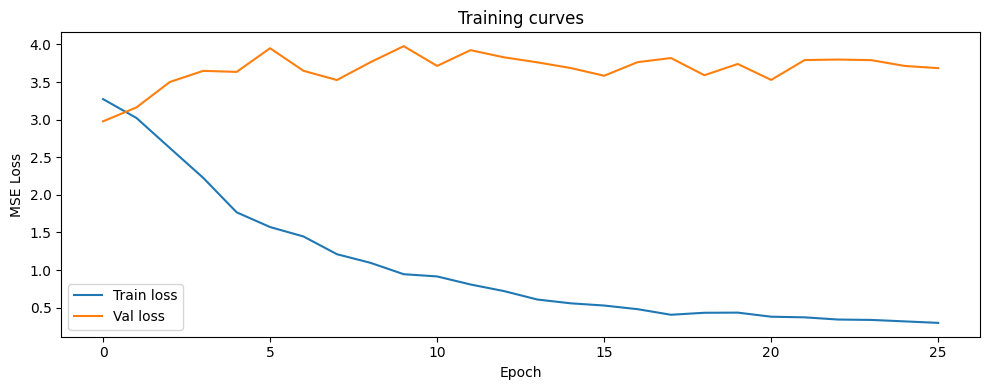

In [34]:
# Cell 8 — Evaluate
model_nn.load_state_dict(best_model_state)
model_nn.eval()

with torch.no_grad():
    train_preds_np = model_nn(X_train_t.to(device)).cpu().numpy().flatten()
    test_preds_np  = model_nn(X_test_t.to(device)).cpu().numpy().flatten()

print(f"""
Results:
  Train R²:  {r2_score(y_train, train_preds_np):.3f}
  Test  R²:  {r2_score(y_test,  test_preds_np):.3f}
  Test  MAE: {mean_absolute_error(y_test, test_preds_np):.3f}
""")

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training curves")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# Cell 9 — Save to Drive
torch.save(
    {
        "model_state": best_model_state,
        "input_dim":   X_train.shape[1],
        "scaler_mean": scaler.mean_,
        "scaler_std":  scaler.scale_,
    },
    f"{BASE}/roi_predictor.pt"
)
print("Model saved to Drive")

Model saved to Drive


In [36]:
# Cell 9 — Install and setup Captum
!pip install captum -q

from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Make sure we're using the best model
model_nn.load_state_dict(best_model_state)
model_nn.eval()

ig = IntegratedGradients(model_nn)
print("Captum ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 16.5 MB/s eta 0:00:00
Captum ready


In [38]:
# Cell 10 — Compute attributions for every test script

def get_attributions(input_array):
    """
    Compute integrated gradient attributions for one script.
    input_array: numpy array of shape (2560,)
    Returns attribution array of shape (2560,)
    """
    input_tensor = torch.tensor(
        input_array, dtype=torch.float32
    ).unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    # Baseline is a zero vector — represents no information
    baseline = torch.zeros_like(input_tensor)

    attributions, delta = ig.attribute(
        input_tensor,
        baseline,
        n_steps=200,
        return_convergence_delta=True
    )

    return (
        attributions.squeeze().cpu().detach().numpy(),
        delta.item()
    )


# Run on all test scripts
print("Computing attributions for test set...\n")

all_attrs      = []
all_deltas     = []
all_titles     = []
all_actual     = []
all_predicted  = []

# Get test set titles from df_meta using the same split
# We need to recover which rows went to test
# Use the same random_state=42 to reproduce the split
_, X_test_idx = train_test_split(
    np.arange(len(X_scaled)),
    test_size=0.2,
    random_state=42
)

for i, idx in enumerate(X_test_idx):
    title  = df_meta.iloc[idx]["title"]
    actual = y[idx]

    attrs, delta = get_attributions(X_scaled[idx])

    with torch.no_grad():
        pred = model_nn(
            torch.tensor(X_scaled[idx], dtype=torch.float32)
            .unsqueeze(0).to(device)
        ).item()

    all_attrs.append(attrs)
    all_deltas.append(delta)
    all_titles.append(title)
    all_actual.append(actual)
    all_predicted.append(pred)

    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(X_test_idx)} done")

all_attrs = np.stack(all_attrs)   # shape (n_test, 2560)
print(f"\nAttribution matrix shape: {all_attrs.shape}")
print(f"Mean convergence delta:   {np.mean(np.abs(all_deltas)):.6f}")
print("Delta close to 0 = attributions are accurate")

Computing attributions for test set...

  20/260 done
  40/260 done
  60/260 done
  80/260 done
  100/260 done
  120/260 done
  140/260 done
  160/260 done
  180/260 done
  200/260 done
  220/260 done
  240/260 done
  260/260 done

Attribution matrix shape: (260, 2560)
Mean convergence delta:   0.000000
Delta close to 0 = attributions are accurate


Top 20 most influential embedding dimensions globally:
Rank   Dim      Mean |Attribution|  
------------------------------------
1      321      0.006900
2      2529     0.006653
3      2309     0.006011
4      1002     0.005997
5      1539     0.005774
6      1390     0.005595
7      1317     0.005572
8      443      0.005428
9      915      0.005402
10     323      0.005377
11     1384     0.005280
12     1547     0.005199
13     247      0.005187
14     2139     0.005128
15     1935     0.005089
16     1244     0.005074
17     2124     0.005026
18     921      0.005025
19     879      0.004989
20     28       0.004941


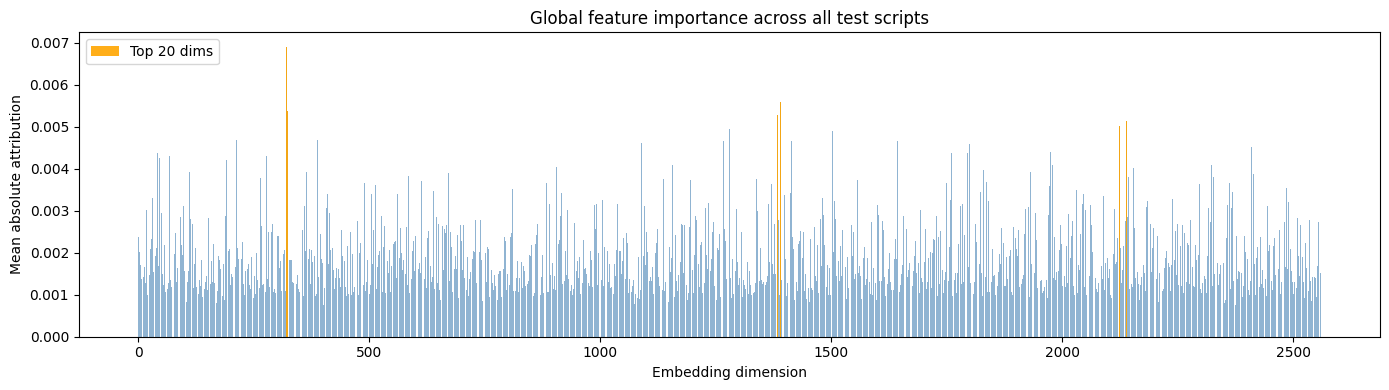

In [39]:
# Cell 11 — Global analysis: which dimensions matter most overall

# Average absolute attribution across all test scripts
# High value = this dimension consistently influenced predictions
mean_abs_attr = np.abs(all_attrs).mean(axis=0)   # shape (2560,)

# Top 20 most influential dimensions globally
top_dims = np.argsort(mean_abs_attr)[-20:][::-1]

print("Top 20 most influential embedding dimensions globally:")
print(f"{'Rank':<6} {'Dim':<8} {'Mean |Attribution|':<20}")
print("-" * 36)
for rank, dim in enumerate(top_dims):
    print(f"{rank+1:<6} {dim:<8} {mean_abs_attr[dim]:.6f}")

# Plot
plt.figure(figsize=(14, 4))
plt.bar(range(len(mean_abs_attr)), mean_abs_attr, alpha=0.6, color="steelblue")
plt.bar(top_dims, mean_abs_attr[top_dims], alpha=0.9, color="orange", label="Top 20 dims")
plt.xlabel("Embedding dimension")
plt.ylabel("Mean absolute attribution")
plt.title("Global feature importance across all test scripts")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# Cell 12 — Per-script analysis: best and worst predictions

results_df = pd.DataFrame({
    "movie_title": all_titles,
    "actual_log_roi":    all_actual,
    "predicted_log_roi": all_predicted,
    "abs_error": np.abs(np.array(all_actual) - np.array(all_predicted))
})

print("Best predictions (lowest error):")
print(results_df.nsmallest(5, "abs_error")[
    ["movie_title", "actual_log_roi", "predicted_log_roi", "abs_error"]
].to_string(index=False))

print("\nWorst predictions (highest error):")
print(results_df.nlargest(5, "abs_error")[
    ["movie_title", "actual_log_roi", "predicted_log_roi", "abs_error"]
].to_string(index=False))

Best predictions (lowest error):
            movie_title  actual_log_roi  predicted_log_roi  abs_error
            End of Days        0.751416           0.751342   0.000074
   Being John Malkovich        0.564597           0.562262   0.002334
      Gangs of New York        0.661515           0.666859   0.005344
  An Affair to Remember        0.593064           0.599334   0.006271
Angels with Dirty Faces        0.987913           0.994191   0.006278

Worst predictions (highest error):
        movie_title  actual_log_roi  predicted_log_roi  abs_error
       The Gardener       -7.647575           0.810988   8.458563
         The Idiots       -5.849965           0.532617   6.382582
Night of the Demons       -5.050832           0.893794   5.944626
The Boondock Saints       -5.055214           0.522779   5.577993
           Mudbound       -4.756516           0.509407   5.265924


Film:            End of Days
Actual log_roi:  0.751
Predicted:       0.751
Error:           0.000

Top 10 dims pushing ROI prediction UP:
  Dim 2459: +0.02510
  Dim 1190: +0.02290
  Dim 1539: +0.01930
  Dim 2521: +0.01713
  Dim 1823: +0.01619
  Dim 1497: +0.01493
  Dim  669: +0.01484
  Dim  655: +0.01473
  Dim 1487: +0.01448
  Dim 2141: +0.01411

Top 10 dims pushing ROI prediction DOWN:
  Dim 1414: -0.02176
  Dim 2265: -0.01865
  Dim 1457: -0.01621
  Dim 1522: -0.01618
  Dim 1244: -0.01548
  Dim  472: -0.01486
  Dim  723: -0.01432
  Dim  566: -0.01426
  Dim 2486: -0.01414
  Dim 1216: -0.01410


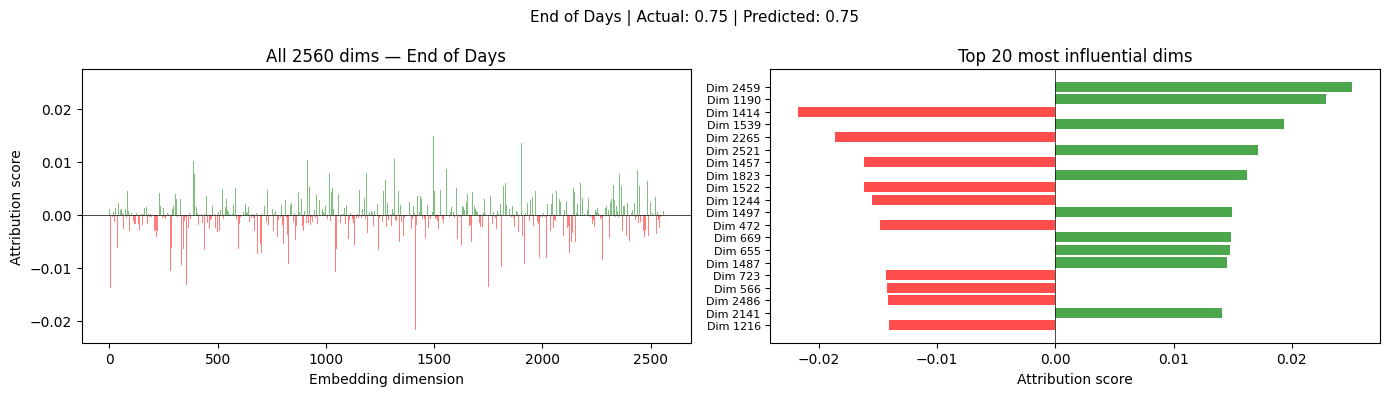

In [42]:
# Cell 13 — Deep dive: attribution breakdown for one specific film

def analyze_film(title):
    """
    Show which embedding dimensions drove the ROI prediction
    for a specific film, and map them back to script passages.
    """
    # Find this film in test set
    if title not in all_titles:
        print(f"'{title}' not in test set")
        print(f"Available: {all_titles[:10]}...")
        return

    i        = all_titles.index(title)
    attrs    = all_attrs[i]          # shape (2560,)
    actual   = all_actual[i]
    pred     = all_predicted[i]

    print(f"Film:            {title}")
    print(f"Actual log_roi:  {actual:.3f}")
    print(f"Predicted:       {pred:.3f}")
    print(f"Error:           {abs(actual - pred):.3f}")

    # Dimensions that pushed prediction UP (positive attribution)
    top_pos = np.argsort(attrs)[-10:][::-1]
    # Dimensions that pushed prediction DOWN (negative attribution)
    top_neg = np.argsort(attrs)[:10]

    print(f"\nTop 10 dims pushing ROI prediction UP:")
    for dim in top_pos:
        print(f"  Dim {dim:4d}: +{attrs[dim]:.5f}")

    print(f"\nTop 10 dims pushing ROI prediction DOWN:")
    for dim in top_neg:
        print(f"  Dim {dim:4d}: {attrs[dim]:.5f}")

    # Bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: full attribution spectrum
    colors = ["green" if v > 0 else "red" for v in attrs]
    axes[0].bar(range(len(attrs)), attrs, color=colors, alpha=0.5)
    axes[0].axhline(0, color="black", linewidth=0.5)
    axes[0].set_xlabel("Embedding dimension")
    axes[0].set_ylabel("Attribution score")
    axes[0].set_title(f"All 2560 dims — {title}")

    # Right: top 20 most influential dims only
    top_combined = np.argsort(np.abs(attrs))[-20:]
    vals   = attrs[top_combined]
    colors = ["green" if v > 0 else "red" for v in vals]
    axes[1].barh(range(20), vals, color=colors, alpha=0.7)
    axes[1].set_yticks(range(20))
    axes[1].set_yticklabels([f"Dim {d}" for d in top_combined], fontsize=8)
    axes[1].axvline(0, color="black", linewidth=0.5)
    axes[1].set_xlabel("Attribution score")
    axes[1].set_title("Top 20 most influential dims")

    plt.suptitle(
        f"{title} | Actual: {actual:.2f} | Predicted: {pred:.2f}",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

    return attrs


# Run on your best predicted film
best_film = results_df.nsmallest(1, "abs_error")["movie_title"].values[0]
attrs_best = analyze_film(best_film)

In [47]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F
import gc

MODEL_NAME = "Qwen/Qwen3-Embedding-4B"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Loading model...")
model = AutoModel.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()

INSTRUCTION = (
    "Instruct: Represent this screenplay for predicting "
    "box office ROI based on genre, tone, and narrative structure\n"
    "Query: "
)
MAX_CHUNK_TOKENS = 8000
INSTRUCTION_TOKEN_LEN = len(tokenizer.encode(INSTRUCTION))

print(f"Ready on: {device}")
print(f"GPU memory used: {torch.cuda.memory_allocated()/1e9:.1f} GB")

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Ready on: cuda
GPU memory used: 8.1 GB


In [48]:
# Cell 14 — Map high-attribution dimensions back to script passages
def read_script(path):
    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            return f.read().strip()
    except FileNotFoundError:
        alt_path = f"/content/gdrive/Shareddrives/FML_FINAL/scripts/{os.path.basename(path)}"
        try:
            with open(alt_path, "r", encoding="utf-8", errors="ignore") as f:
                return f.read().strip()
        except FileNotFoundError:
            print(f"  WARNING: Could not find script at {path}")
            return None

# Test it works on the best film
print(f"Looking for: {best_film}")
path = df_meta[df_meta["title"] == best_film]["script_file"].values[0]
print(f"Path in CSV: {path}")
text = read_script(path)
print(f"Found: {text is not None}")
if text:
    print(f"Length: {len(text.split())} words")


def find_script_passages(title, attribution_vector, top_k=5):
    """
    Splits the script into small chunks, embeds each,
    and scores them by alignment with high-attribution dims.
    The chunks with the highest scores are the passages
    the model leaned on most for its ROI prediction.
    """
    # Get script path
    matches = df_meta[df_meta["title"] == title]
    if len(matches) == 0:
        print(f"Not found: {title}")
        return

    path = matches["script_file"].values[0]
    script_text = read_script(path)
    if script_text is None:
        print("Script file not found on disk")
        return

    # Split into small chunks for precise localization
    PASSAGE_TOKENS = 300
    tokens = tokenizer.encode(script_text, add_special_tokens=False)

    chunks = []
    for start in range(0, len(tokens), PASSAGE_TOKENS):
        end = min(start + PASSAGE_TOKENS, len(tokens))
        chunk_text = tokenizer.decode(tokens[start:end], skip_special_tokens=True)
        chunks.append((start, end, chunk_text))

    print(f"Script split into {len(chunks)} passages of ~{PASSAGE_TOKENS} tokens\n")

    # Embed each passage and score against attribution vector
    passage_scores = []

    for start, end, chunk_text in chunks:
        inputs = tokenizer(
            INSTRUCTION + chunk_text,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_CHUNK_TOKENS + INSTRUCTION_TOKEN_LEN,
            padding=False
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        import torch.nn.functional as F
        vec = outputs.last_hidden_state[:, -1, :]
        vec = F.normalize(vec, p=2, dim=1)
        vec_np = vec.squeeze().cpu().float().numpy()

        # Score = dot product of passage embedding with attribution vector
        # High score = this passage activates the influential dimensions
        score = np.dot(vec_np, attribution_vector)
        passage_scores.append((score, start, end, chunk_text))

        del inputs, outputs, vec
        torch.cuda.empty_cache()

    # Sort and show top passages
    passage_scores.sort(reverse=True)

    print(f"Top {top_k} most attribution-relevant passages in '{title}':")
    print("=" * 60)

    for rank, (score, start, end, text) in enumerate(passage_scores[:top_k]):
        print(f"\nRank {rank+1} | Score: {score:.4f} | Tokens {start}-{end}")
        print("-" * 40)
        print(text[:400].strip())
        print("...")


# Run on the best predicted film
find_script_passages(best_film, attrs_best, top_k=5)

Looking for: End of Days
Path in CSV: /content/gdrive/Shareddrives/FML_FINAL/Data/Anyis_Script/Movie-Script-Database/scripts/filtered/EndOfDays.txt
Found: True
Length: 27733 words
Script split into 140 passages of ~300 tokens

Top 5 most attribution-relevant passages in 'End of Days':

Rank 1 | Score: -0.0005 | Tokens 1800-2100
----------------------------------------
, do you copy?
EXT. ROOFTOP - DAY
This black tar roof looks like it hasn't seen maintenance
since the WPA. Bracketed to building's edge, fifteen foot
letters extend high above us telling any New Yorker who
bothers to look up that once-upon-a-time this was...
TBE

BLUE

ANGEL

BOTEL.

A HELICOPTER rises above the edge of the building and circles
the rooftop perimeter.
-HELICOPTER PILOT TWO
Hunter T
...

Rank 2 | Score: -0.0009 | Tokens 37800-38100
----------------------------------------
through the air. Be
lands on the steps of the temple, his momentum sending *»<-"
tumbling down.
THE BEAST claws down the stone steps.

Th

Low ROI films:  ['The Gardener', 'The Idiots', 'The Boondock Saints', 'Night of the Demons', 'Mudbound']
High ROI films: ['Seven Samurai', 'Dr. No', 'Jaws', 'Napoleon Dynamite', 'El Mariachi']

Dimensions most active in HIGH ROI films:
  Dim  561: diff=+0.00887
  Dim  408: diff=+0.00815
  Dim 1499: diff=+0.00721
  Dim 2391: diff=+0.00689
  Dim 2327: diff=+0.00671
  Dim 2184: diff=+0.00666
  Dim  463: diff=+0.00640
  Dim  289: diff=+0.00627
  Dim 1643: diff=+0.00622
  Dim 1935: diff=+0.00617
  Dim   98: diff=+0.00614
  Dim  365: diff=+0.00604
  Dim  902: diff=+0.00596
  Dim 1748: diff=+0.00591
  Dim 1265: diff=+0.00581

Dimensions most active in LOW ROI films:
  Dim 1251: diff=-0.00824
  Dim 2362: diff=-0.00815
  Dim 1195: diff=-0.00750
  Dim  111: diff=-0.00714
  Dim 1364: diff=-0.00702
  Dim  411: diff=-0.00697
  Dim 1216: diff=-0.00695
  Dim 1764: diff=-0.00695
  Dim 2521: diff=-0.00662
  Dim  274: diff=-0.00630
  Dim 1772: diff=-0.00581
  Dim 1758: diff=-0.00569
  Dim  757: diff=-0.

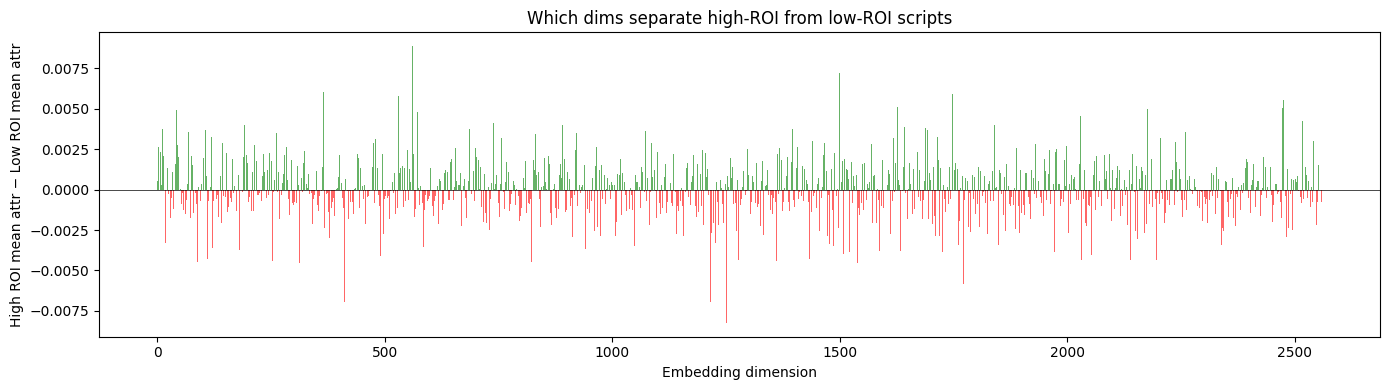

In [49]:
# Cell 15 — Compare high ROI vs low ROI films

def compare_high_low_roi(n=5):
    """
    Compare which embedding dimensions are active
    in high-ROI vs low-ROI films.
    Reveals what the model associates with commercial success.
    """
    results_sorted = results_df.sort_values("actual_log_roi")

    low_titles  = results_sorted.head(n)["movie_title"].tolist()
    high_titles = results_sorted.tail(n)["movie_title"].tolist()

    low_attrs  = np.stack([all_attrs[all_titles.index(t)] for t in low_titles])
    high_attrs = np.stack([all_attrs[all_titles.index(t)] for t in high_titles])

    low_mean  = low_attrs.mean(axis=0)
    high_mean = high_attrs.mean(axis=0)
    diff      = high_mean - low_mean   # positive = more active in high-ROI films

    top_high_dims = np.argsort(diff)[-15:][::-1]
    top_low_dims  = np.argsort(diff)[:15]

    print(f"Low ROI films:  {low_titles}")
    print(f"High ROI films: {high_titles}")

    print(f"\nDimensions most active in HIGH ROI films:")
    for dim in top_high_dims:
        print(f"  Dim {dim:4d}: diff={diff[dim]:+.5f}")

    print(f"\nDimensions most active in LOW ROI films:")
    for dim in top_low_dims:
        print(f"  Dim {dim:4d}: diff={diff[dim]:+.5f}")

    # Plot
    plt.figure(figsize=(14, 4))
    plt.bar(range(len(diff)), diff,
            color=["green" if v > 0 else "red" for v in diff],
            alpha=0.6)
    plt.axhline(0, color="black", linewidth=0.5)
    plt.xlabel("Embedding dimension")
    plt.ylabel("High ROI mean attr − Low ROI mean attr")
    plt.title("Which dims separate high-ROI from low-ROI scripts")
    plt.tight_layout()
    plt.show()


compare_high_low_roi(n=5)

In [50]:
# Cell 16 — Save attribution results
np.save(f"{BASE}/test_attributions.npy", all_attrs)
results_df.to_csv(f"{BASE}/test_predictions.csv", index=False)
print("Saved attributions and predictions to Drive")

Saved attributions and predictions to Drive


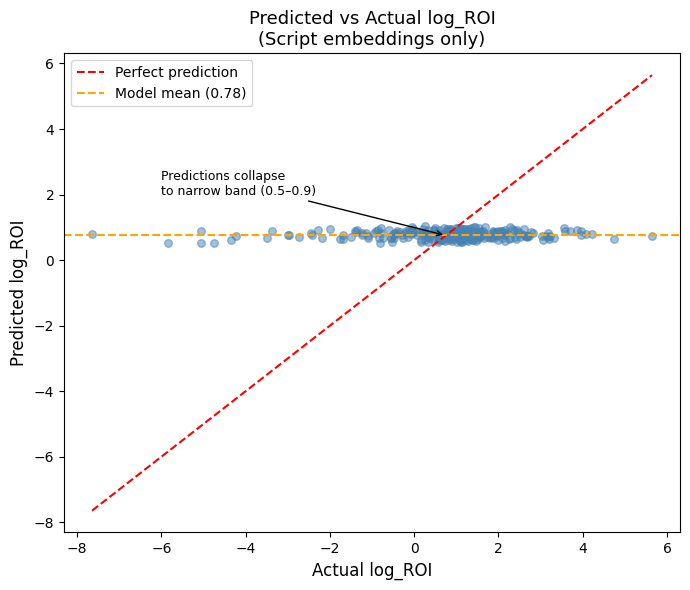

In [51]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, test_preds_np, alpha=0.5, color="steelblue", s=30)

# Perfect prediction line
lims = [min(y_test.min(), test_preds_np.min()),
        max(y_test.max(), test_preds_np.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label="Perfect prediction")

# Mean prediction line
ax.axhline(y=np.mean(test_preds_np), color='orange',
           linewidth=1.5, linestyle='--', label=f"Model mean ({np.mean(test_preds_np):.2f})")

ax.set_xlabel("Actual log_ROI", fontsize=12)
ax.set_ylabel("Predicted log_ROI", fontsize=12)
ax.set_title("NN: Predicted vs Actual log_ROI", fontsize=13)
ax.legend()

# Annotate the collapsed prediction range
ax.annotate("Predictions collapse\nto narrow band (0.5–0.9)",
            xy=(0.75, 0.75), xytext=(-6, 2),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9)

plt.tight_layout()
plt.savefig(f"{BASE}/actual_vs_predicted.png", dpi=150)
plt.show()

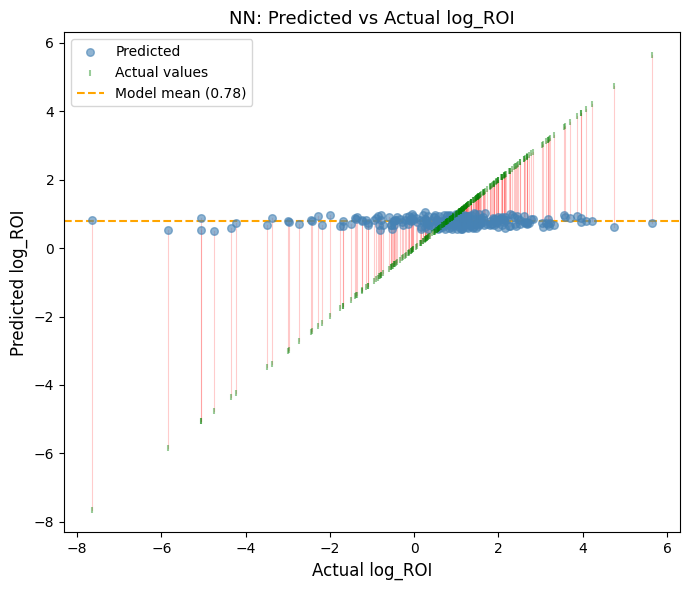

In [52]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 6))

# Draw vertical lines from each prediction down to its actual value
# This shows the error for every film visually
for actual, pred in zip(y_test, test_preds_np):
    ax.plot([actual, actual], [actual, pred],
            color="red", alpha=0.2, linewidth=0.8)

# Plot the dots on top
ax.scatter(y_test, test_preds_np,
           alpha=0.6, color="steelblue", s=30, label="Predicted", zorder=3)

# Plot actual values as markers on the x axis
ax.scatter(y_test, y_test,
           alpha=0.4, color="green", s=15, marker="|",
           label="Actual values", zorder=3)

# Model mean line
ax.axhline(y=np.mean(test_preds_np), color='orange',
           linewidth=1.5, linestyle='--',
           label=f"Model mean ({np.mean(test_preds_np):.2f})")

ax.set_xlabel("Actual log_ROI", fontsize=12)
ax.set_ylabel("Predicted log_ROI", fontsize=12)
ax.set_title("NN: Predicted vs Actual log_ROI", fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig(f"{BASE}/actual_vs_predicted.png", dpi=150)
plt.show()

Low ROI films:  ['The Gardener', 'The Idiots', 'The Boondock Saints', 'Night of the Demons', 'Mudbound']
High ROI films: ['Seven Samurai', 'Dr. No', 'Jaws', 'Napoleon Dynamite', 'El Mariachi']
diff shape: (2560,)
Max positive diff: 0.00887
Max negative diff: -0.00824


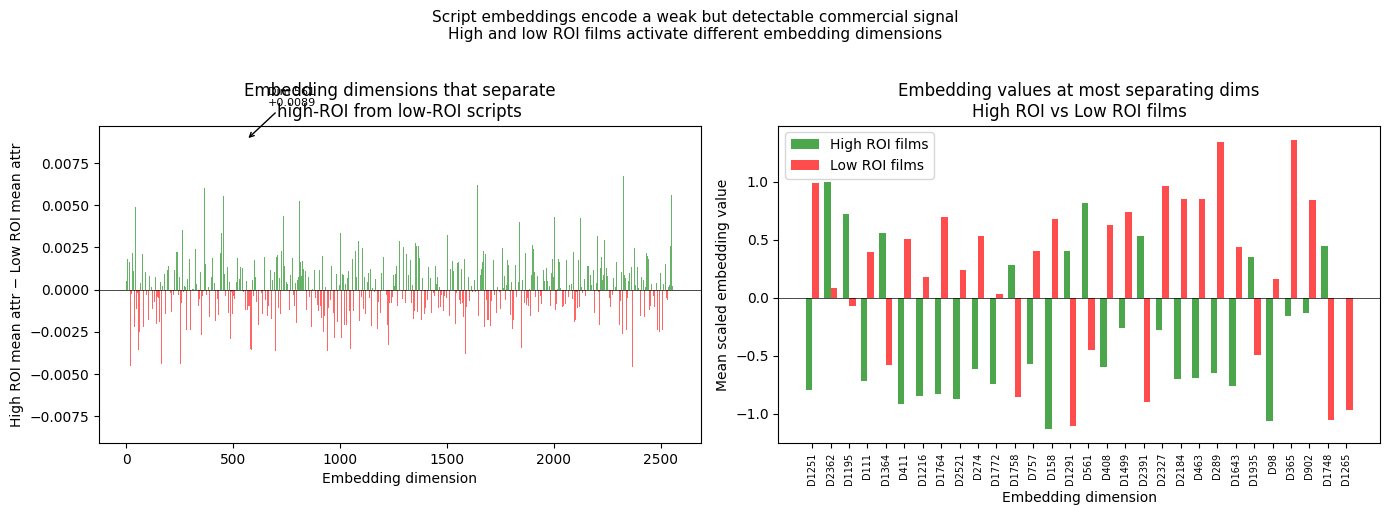

Max separation between high/low ROI: 0.0089
Average separation across all dims:  0.0013
Signal to noise ratio:               6.7x


In [54]:
n = 5

results_sorted = results_df.sort_values("actual_log_roi")
low_titles  = results_sorted.head(n)["movie_title"].tolist()
high_titles = results_sorted.tail(n)["movie_title"].tolist()

print(f"Low ROI films:  {low_titles}")
print(f"High ROI films: {high_titles}")

low_attrs  = np.stack([all_attrs[all_titles.index(t)] for t in low_titles if t in all_titles])
high_attrs = np.stack([all_attrs[all_titles.index(t)] for t in high_titles if t in all_titles])

low_mean  = low_attrs.mean(axis=0)
high_mean = high_attrs.mean(axis=0)
diff      = high_mean - low_mean

print(f"diff shape: {diff.shape}")
print(f"Max positive diff: {diff.max():.5f}")
print(f"Max negative diff: {diff.min():.5f}")



import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left chart: the separation chart you already have ---
axes[0].bar(range(len(diff)), diff,
            color=["green" if v > 0 else "red" for v in diff],
            alpha=0.6)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_xlabel("Embedding dimension")
axes[0].set_ylabel("High ROI mean attr − Low ROI mean attr")
axes[0].set_title("Embedding dimensions that separate\nhigh-ROI from low-ROI scripts")

# Annotate the strongest separating dim
top_dim = np.argmax(diff)
axes[0].annotate(f"Dim {top_dim}\n+{diff[top_dim]:.4f}",
                 xy=(top_dim, diff[top_dim]),
                 xytext=(top_dim + 100, diff[top_dim] + 0.002),
                 arrowprops=dict(arrowstyle="->", color="black"),
                 fontsize=8)

# --- Right chart: show the actual embedding values at top dims ---
# This makes it concrete — what values do high vs low ROI films
# have at the most separating dimensions

# Get indices of top 15 separating dims in each direction
top_pos_dims = np.argsort(diff)[-15:][::-1]
top_neg_dims = np.argsort(diff)[:15]
top_dims_combined = np.concatenate([top_neg_dims, top_pos_dims])

# Get embedding vectors for high and low ROI test films
low_titles  = results_df.nsmallest(5, "actual_log_roi")["movie_title"].tolist()
high_titles = results_df.nlargest(5, "actual_log_roi")["movie_title"].tolist()

low_indices  = [all_titles.index(t) for t in low_titles if t in all_titles]
high_indices = [all_titles.index(t) for t in high_titles if t in all_titles]

# Use the scaled embeddings at the test indices
_, X_test_idx = train_test_split(
    np.arange(len(X_scaled)), test_size=0.2, random_state=42
)

low_vecs  = np.stack([X_scaled[X_test_idx[i]] for i in low_indices])
high_vecs = np.stack([X_scaled[X_test_idx[i]] for i in high_indices])

low_means  = low_vecs.mean(axis=0)[top_dims_combined]
high_means = high_vecs.mean(axis=0)[top_dims_combined]

x = np.arange(len(top_dims_combined))
width = 0.35

axes[1].bar(x - width/2, high_means, width,
            label="High ROI films", color="green", alpha=0.7)
axes[1].bar(x + width/2, low_means, width,
            label="Low ROI films", color="red", alpha=0.7)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f"D{d}" for d in top_dims_combined],
    rotation=90, fontsize=7
)
axes[1].set_xlabel("Embedding dimension")
axes[1].set_ylabel("Mean scaled embedding value")
axes[1].set_title("Embedding values at most separating dims\nHigh ROI vs Low ROI films")
axes[1].legend()

plt.suptitle(
    "Script embeddings encode a weak but detectable commercial signal\n"
    "High and low ROI films activate different embedding dimensions",
    fontsize=11, y=1.02
)

plt.tight_layout()
plt.savefig(f"{BASE}/roi_separation_dims.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the key stat for your poster
print(f"Max separation between high/low ROI: {diff.max():.4f}")
print(f"Average separation across all dims:  {np.abs(diff).mean():.4f}")
print(f"Signal to noise ratio:               {diff.max() / np.abs(diff).mean():.1f}x")